B-1 : SETUP AND LOAD DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── LOAD RAW FILES ─────────────────────────────────────────────────────────
transaction = pd.read_excel('../data/QVI_transaction_data (1).xlsx')
purchase    = pd.read_csv('../data/QVI_purchase_behaviour (1).csv')

# ── FIX DATE ───────────────────────────────────────────────────────────────
transaction['DATE'] = pd.to_datetime(transaction['DATE'],
                                      origin='1899-12-30', unit='D')

# ── DERIVE PACK SIZE & BRAND ───────────────────────────────────────────────
transaction['PACK_SIZE'] = (transaction['PROD_NAME']
                             .str.extract(r'(\d+)g', expand=False)
                             .astype(float))

transaction['BRAND'] = transaction['PROD_NAME'].str.split().str[0].str.upper()
brand_map = {'SNBTS':'SUNBITES','INFZNS':'INFUZIONS','WW':'WOOLWORTHS',
             'SMITH':'SMITHS','NCC':'NATURAL','DORITO':'DORITOS','GRAIN':'GRNWVES'}
transaction['BRAND'] = transaction['BRAND'].replace(brand_map)

# ── REMOVE OUTLIERS ────────────────────────────────────────────────────────
transaction = transaction[transaction['PROD_QTY'] <= 5]

# ── MERGE ──────────────────────────────────────────────────────────────────
df = transaction.merge(purchase, on='LYLTY_CARD_NBR', how='left')

print(f"Merged shape: {df.shape}")
print(df.head(3))

Merged shape: (264834, 12)
        DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0 2018-10-17          1            1000       1         5   
1 2019-05-14          1            1307     348        66   
2 2019-05-20          1            1343     383        61   

                                PROD_NAME  PROD_QTY  TOT_SALES  PACK_SIZE  \
0  Natural Chip        Compny SeaSalt175g         2        6.0      175.0   
1                CCs Nacho Cheese    175g         3        6.3      175.0   
2  Smiths Crinkle Cut  Chips Chicken 170g         2        2.9      170.0   

     BRAND               LIFESTAGE PREMIUM_CUSTOMER  
0  NATURAL   YOUNG SINGLES/COUPLES          Premium  
1      CCS  MIDAGE SINGLES/COUPLES           Budget  
2   SMITHS  MIDAGE SINGLES/COUPLES           Budget  


B-2 : CREATE MONTHLY STORE LEVEL METRICS

In [3]:
# ── ADD YEAR-MONTH COLUMN ──────────────────────────────────────────────────
df['YEAR_MONTH'] = df['DATE'].dt.to_period('M')

# ── AGGREGATE TO MONTHLY STORE GRAIN ──────────────────────────────────────
monthly = df.groupby(['STORE_NBR', 'YEAR_MONTH']).agg(
    total_sales      = ('TOT_SALES',       'sum'),
    total_customers  = ('LYLTY_CARD_NBR',  'nunique'),
    total_txns       = ('TXN_ID',          'count')
).reset_index()

monthly['avg_txns_per_customer'] = (
    monthly['total_txns'] / monthly['total_customers']
)

# ── DEFINE TRIAL STORES & PERIODS ─────────────────────────────────────────
TRIAL_STORES  = [77, 86, 88]
PRE_TRIAL     = monthly['YEAR_MONTH'] < pd.Period('2019-02', 'M')
TRIAL_PERIOD  = (monthly['YEAR_MONTH'] >= pd.Period('2019-02', 'M')) & \
                (monthly['YEAR_MONTH'] <= pd.Period('2019-04', 'M'))

pre_trial_df  = monthly[PRE_TRIAL]
trial_df      = monthly[TRIAL_PERIOD]

print("Pre-trial months:", sorted(pre_trial_df['YEAR_MONTH'].unique()))
print("Trial months    :", sorted(trial_df['YEAR_MONTH'].unique()))
print("All stores      :", sorted(monthly['STORE_NBR'].unique()))

Pre-trial months: [Period('2018-07', 'M'), Period('2018-08', 'M'), Period('2018-09', 'M'), Period('2018-10', 'M'), Period('2018-11', 'M'), Period('2018-12', 'M'), Period('2019-01', 'M')]
Trial months    : [Period('2019-02', 'M'), Period('2019-03', 'M'), Period('2019-04', 'M')]
All stores      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51)

B - 3 : CONTROL STORE SELECTION FUNCTION

In [4]:
def get_control_store(trial_store, metric='total_sales', top_n=5):
    """
    For a given trial store, score all candidate control stores
    using Pearson correlation + normalised magnitude distance
    on the pre-trial window. Returns ranked candidates df + best match.
    """
    # pivot: rows = YEAR_MONTH, cols = STORE_NBR
    pivot = pre_trial_df.pivot(index='YEAR_MONTH',
                                columns='STORE_NBR',
                                values=metric).dropna(axis=1)

    if trial_store not in pivot.columns:
        print(f"Store {trial_store} not found in pre-trial data.")
        return None, None

    trial_series = pivot[trial_store]
    candidates   = [c for c in pivot.columns
                    if c not in TRIAL_STORES and c != trial_store]

    results = []
    for store in candidates:
        cand_series = pivot[store]

        # Pearson correlation
        corr, _ = stats.pearsonr(trial_series, cand_series)

        # Magnitude distance (Euclidean), then normalise
        dist = np.sqrt(((trial_series - cand_series) ** 2).sum())
        results.append({'store': store, 'corr': corr, 'dist': dist})

    scores_df = pd.DataFrame(results)

    # Normalise distance → similarity (higher = more similar)
    min_d = scores_df['dist'].min()
    max_d = scores_df['dist'].max()
    scores_df['dist_score'] = (
        1 - (scores_df['dist'] - min_d) / (max_d - min_d)
    )

    # Composite score = average of correlation & distance similarity
    scores_df['composite'] = (scores_df['corr'] + scores_df['dist_score']) / 2
    scores_df = scores_df.sort_values('composite', ascending=False).reset_index(drop=True)

    best_control = int(scores_df.loc[0, 'store'])
    print(f"\nTrial Store {trial_store} → Best Control Store: {best_control}")
    print(scores_df.head(top_n).to_string(index=False))

    return best_control, scores_df


def plot_control_candidates(trial_store, scores_df, metric='total_sales', top_n=5):
    """Visualise pre-trial trend of trial store vs top control candidates."""
    pivot = pre_trial_df.pivot(index='YEAR_MONTH',
                                columns='STORE_NBR',
                                values=metric)
    top_stores   = scores_df.head(top_n)['store'].tolist()
    best_control = int(scores_df.loc[0, 'store'])

    BG      = '#0D1117'
    CARD_BG = '#161B22'
    TEAL    = '#00C9A7'
    GOLD    = '#F5A623'
    DIM     = '#8B9BAA'
    LIGHT   = '#E8EDF2'
    CORAL   = '#FF6B6B'

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)
    months = [str(m) for m in pivot.index]

    # LEFT: trial vs all top candidates
    ax = axes[0]
    ax.set_facecolor(CARD_BG)
    for s in top_stores:
        if s in pivot.columns:
            color = GOLD if s == best_control else '#4A5568'
            lw    = 2.5  if s == best_control else 1
            ax.plot(months, pivot[s], color=color, linewidth=lw,
                    label=f'Store {int(s)}{"  ← BEST CONTROL" if s == best_control else ""}',
                    alpha=0.85)
    ax.plot(months, pivot[trial_store], color=TEAL, linewidth=3,
            label=f'Trial Store {trial_store}', linestyle='--')
    ax.set_title(f'Trial {trial_store}: Top Control Candidates\n({metric})',
                 color=LIGHT, fontsize=12, fontweight='bold')
    ax.set_xlabel('Month', color=DIM, fontsize=9)
    ax.set_ylabel(metric.replace('_', ' ').title(), color=DIM, fontsize=9)
    ax.tick_params(colors=DIM, labelsize=7)
    ax.spines[:].set_visible(False)
    ax.legend(facecolor=CARD_BG, edgecolor=DIM, labelcolor=LIGHT, fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # RIGHT: composite score bar chart
    ax2 = axes[1]
    ax2.set_facecolor(CARD_BG)
    bar_colors = [GOLD if s == best_control else '#4A5568' for s in top_stores]
    bars = ax2.barh([f'Store {int(s)}' for s in top_stores],
                     scores_df.head(top_n)['composite'].values,
                     color=bar_colors, alpha=0.85, height=0.55)
    for bar, val in zip(bars, scores_df.head(top_n)['composite'].values):
        ax2.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', color=LIGHT, fontsize=9)
    ax2.set_title(f'Composite Similarity Score\n(Corr + Magnitude Distance)',
                  color=LIGHT, fontsize=12, fontweight='bold')
    ax2.set_xlabel('Composite Score (higher = more similar)', color=DIM, fontsize=9)
    ax2.tick_params(colors=DIM)
    ax2.spines[:].set_visible(False)
    for lbl in ax2.get_yticklabels():
        lbl.set_color(LIGHT)

    plt.suptitle(f'Control Store Selection — Trial Store {trial_store}',
                 color=LIGHT, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'control_selection_store_{trial_store}.png',
                dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()

B - 4: Run Control Store Selection for All 3 Trial Stores


Trial Store 77 → Best Control Store: 233
 store     corr       dist  dist_score  composite
   233 0.903774  57.809342    1.000000   0.951887
    41 0.783232 130.753432    0.977141   0.880187
    50 0.763866 100.672340    0.986568   0.875217
    17 0.842668 419.490489    0.886660   0.864664
   115 0.689159 247.264312    0.940630   0.814895


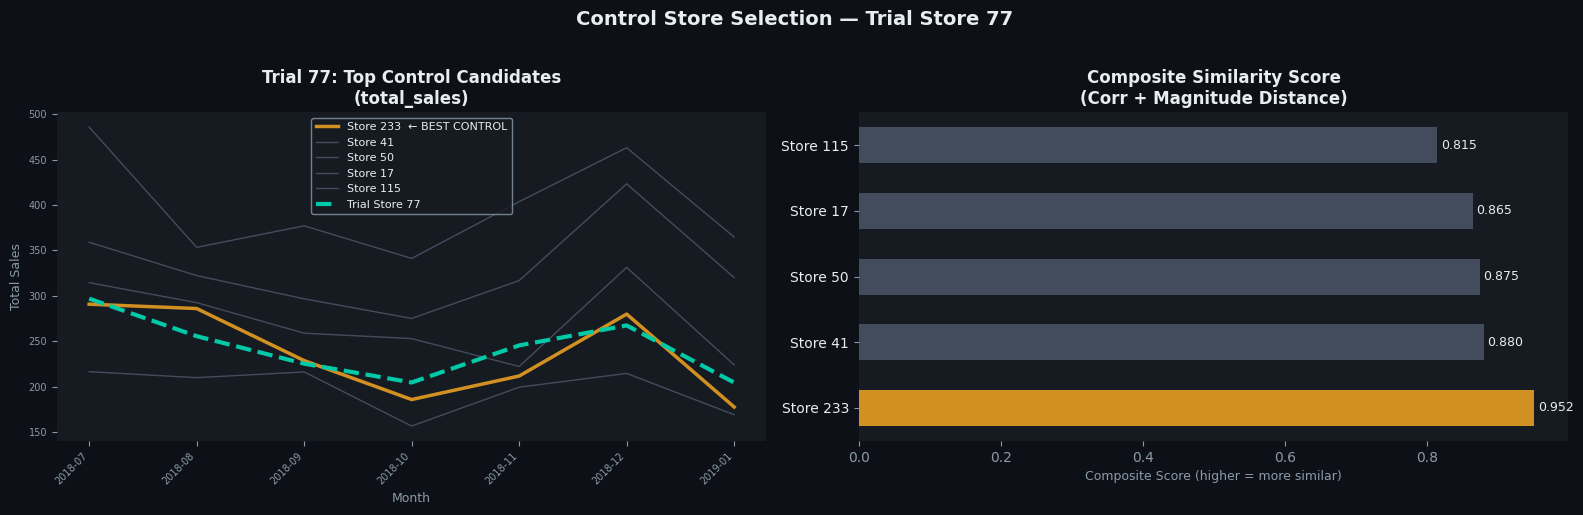


Trial Store 86 → Best Control Store: 155
 store     corr       dist  dist_score  composite
   155 0.877882 114.628192    0.995831   0.936856
   109 0.788300 105.576240    1.000000   0.894150
   222 0.795075 125.467137    0.990840   0.892957
   138 0.759864 191.615820    0.960376   0.860120
   114 0.734415 215.771384    0.949251   0.841833


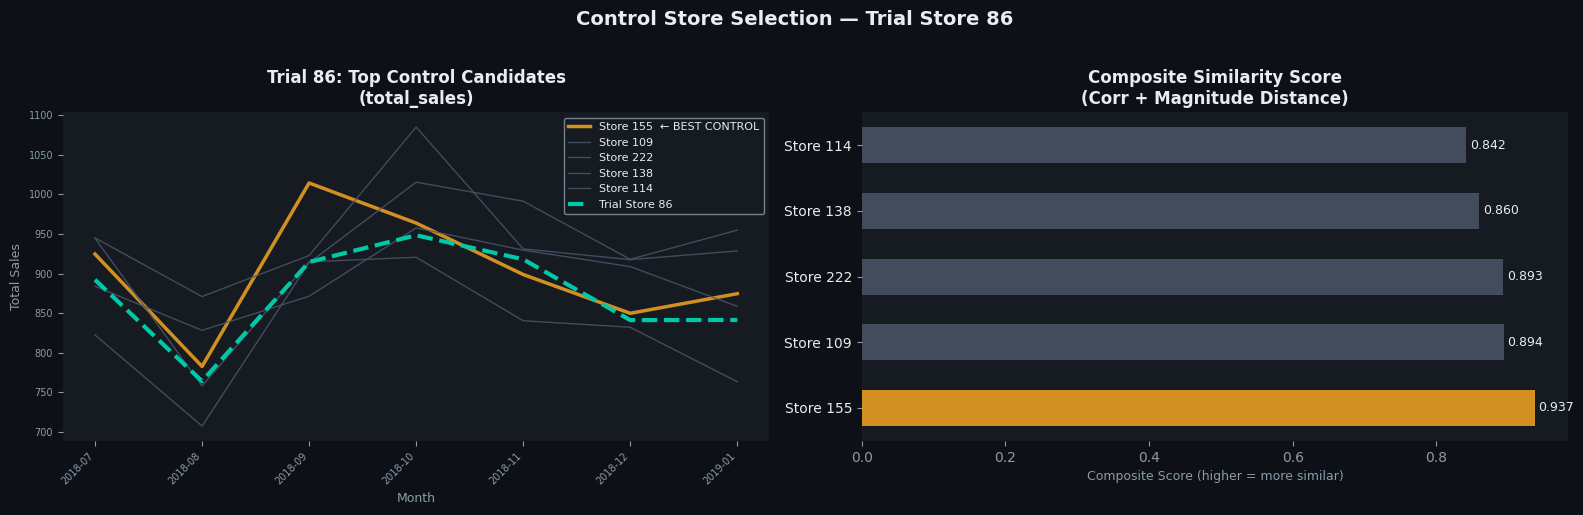


Trial Store 88 → Best Control Store: 125
 store     corr        dist  dist_score  composite
   125 0.624109  535.728068    0.896634   0.760371
   203 0.508001  213.999369    0.993698   0.750850
    91 0.776688 1195.406408    0.697611   0.737150
     7 0.649657  797.830953    0.817558   0.733607
   178 0.731857 1076.713226    0.733420   0.732638


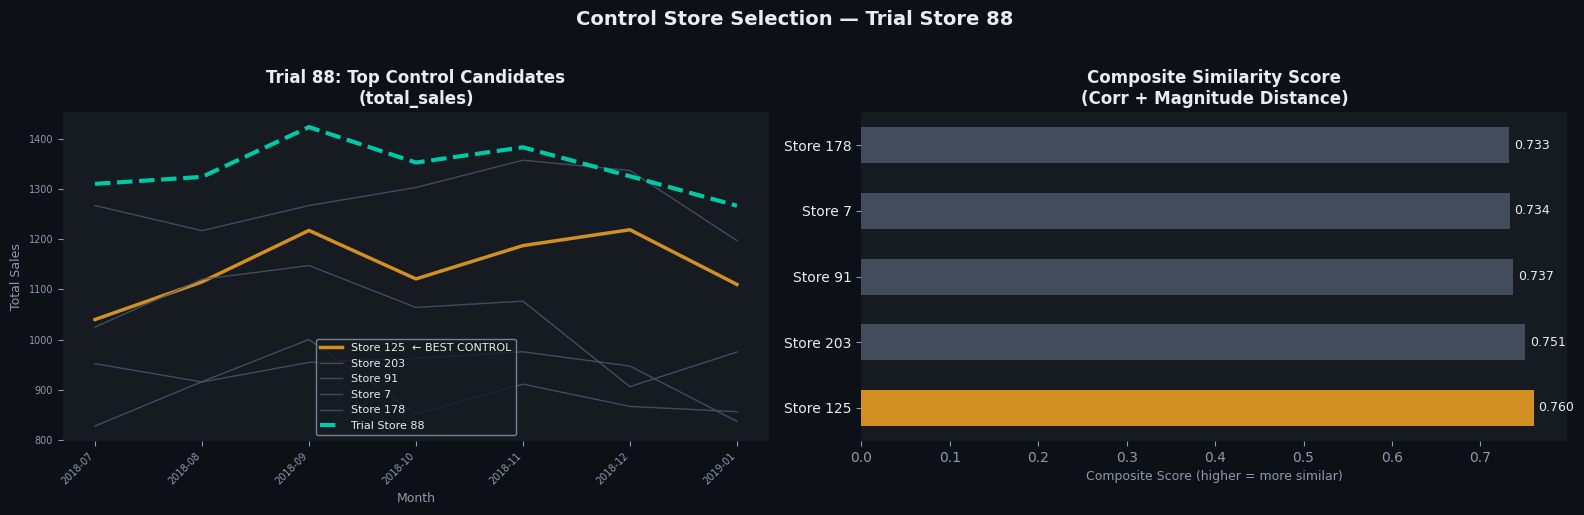


=== CONTROL STORE ASSIGNMENTS ===
Trial Store 77  →  Control Store 233
Trial Store 86  →  Control Store 155
Trial Store 88  →  Control Store 125


In [5]:
# ── RUN FOR STORE 77 ───────────────────────────────────────────────────────
ctrl_77, scores_77 = get_control_store(77, metric='total_sales')
plot_control_candidates(77, scores_77, metric='total_sales')

# ── RUN FOR STORE 86 ───────────────────────────────────────────────────────
ctrl_86, scores_86 = get_control_store(86, metric='total_sales')
plot_control_candidates(86, scores_86, metric='total_sales')

# ── RUN FOR STORE 88 ───────────────────────────────────────────────────────
ctrl_88, scores_88 = get_control_store(88, metric='total_sales')
plot_control_candidates(88, scores_88, metric='total_sales')

# ── SUMMARY ────────────────────────────────────────────────────────────────
print("\n=== CONTROL STORE ASSIGNMENTS ===")
print(f"Trial Store 77  →  Control Store {ctrl_77}")
print(f"Trial Store 86  →  Control Store {ctrl_86}")
print(f"Trial Store 88  →  Control Store {ctrl_88}")

B - 5 : Uplift Testing Function

In [6]:
def uplift_test(trial_store, control_store, metric='total_sales'):
    """
    Scale control store pre-trial metrics to trial store level,
    build 95% CI from pre-trial scaled performance,
    then check if trial months fall outside CI → significant uplift.
    """
    t_pre = (pre_trial_df[pre_trial_df['STORE_NBR'] == trial_store]
             .set_index('YEAR_MONTH')[metric])
    c_pre = (pre_trial_df[pre_trial_df['STORE_NBR'] == control_store]
             .set_index('YEAR_MONTH')[metric])

    # Scaling factor: how much bigger/smaller is trial vs control pre-trial
    scale = t_pre.mean() / c_pre.mean()

    # Scaled control during trial period
    t_trial = (trial_df[trial_df['STORE_NBR'] == trial_store]
               .set_index('YEAR_MONTH')[metric])
    c_trial = (trial_df[trial_df['STORE_NBR'] == control_store]
               .set_index('YEAR_MONTH')[metric])
    c_trial_scaled = c_trial * scale

    # Pre-trial percentage differences (scaled)
    c_pre_scaled  = c_pre * scale
    pct_diffs_pre = (t_pre - c_pre_scaled) / c_pre_scaled

    # 95% CI bounds using pre-trial std
    mean_pct = pct_diffs_pre.mean()
    std_pct  = pct_diffs_pre.std()
    ci_upper = mean_pct + 2 * std_pct
    ci_lower = mean_pct - 2 * std_pct

    # Trial period percentage differences
    pct_diffs_trial = (t_trial - c_trial_scaled) / c_trial_scaled

    print(f"\n{'='*55}")
    print(f"  Trial Store {trial_store}  vs  Control Store {control_store}")
    print(f"  Metric: {metric}")
    print(f"{'='*55}")
    print(f"  Scale factor          : {scale:.4f}")
    print(f"  Pre-trial mean % diff : {mean_pct:.2%}")
    print(f"  95% CI                : [{ci_lower:.2%}, {ci_upper:.2%}]")
    print(f"\n  Trial period % diffs vs scaled control:")
    for month, val in pct_diffs_trial.items():
        flag = 'SIGNIFICANT' if (val > ci_upper or val < ci_lower) else '— within CI'
        print(f"    {month}  :  {val:.2%}  {flag}")

    return {
        'trial_store'     : trial_store,
        'control_store'   : control_store,
        'metric'          : metric,
        'scale'           : scale,
        't_pre'           : t_pre,
        'c_pre_scaled'    : c_pre_scaled,
        't_trial'         : t_trial,
        'c_trial_scaled'  : c_trial_scaled,
        'pct_diffs_pre'   : pct_diffs_pre,
        'pct_diffs_trial' : pct_diffs_trial,
        'ci_upper'        : ci_upper,
        'ci_lower'        : ci_lower,
        'mean_pct'        : mean_pct,
    }

B - 6: Uplift Visualisation Function

In [7]:
def plot_uplift(result):
    BG      = '#0D1117'
    CARD_BG = '#161B22'
    TEAL    = '#00C9A7'
    GOLD    = '#F5A623'
    CORAL   = '#FF6B6B'
    GREEN   = '#2ECC71'
    DIM     = '#8B9BAA'
    LIGHT   = '#E8EDF2'

    ts  = result['trial_store']
    cs  = result['control_store']
    met = result['metric']

    # combine pre + trial for full timeline
    trial_full   = pd.concat([result['t_pre'],   result['t_trial']])
    control_full = pd.concat([result['c_pre_scaled'], result['c_trial_scaled']])

    all_months = sorted(set(trial_full.index) | set(control_full.index))
    months_str = [str(m) for m in all_months]

    # CI band — replicate pre-trial CI over full window
    ci_u = result['ci_upper']
    ci_l = result['ci_lower']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)

    # ── LEFT: Actual sales timeline ──
    ax = axes[0]
    ax.set_facecolor(CARD_BG)

    t_vals = [trial_full.get(m, np.nan)   for m in all_months]
    c_vals = [control_full.get(m, np.nan) for m in all_months]

    ax.plot(months_str, t_vals, color=TEAL, linewidth=2.5,
            marker='o', label=f'Trial Store {ts}')
    ax.plot(months_str, c_vals, color=GOLD, linewidth=2.5,
            marker='s', linestyle='--', label=f'Control Store {cs} (scaled)')

    # shade trial period
    trial_months_str = [str(m) for m in result['t_trial'].index]
    if trial_months_str:
        x0 = months_str.index(trial_months_str[0])
        x1 = months_str.index(trial_months_str[-1])
        ax.axvspan(x0 - 0.5, x1 + 0.5, alpha=0.12, color=GREEN, label='Trial Period')

    ax.axvline(x=months_str.index(trial_months_str[0]) - 0.5,
               color=CORAL, linestyle=':', linewidth=1.5)

    ax.set_title(f'Store {ts} vs Control {cs}\n{met.replace("_"," ").title()} Over Time',
                 color=LIGHT, fontsize=12, fontweight='bold')
    ax.set_xlabel('Month', color=DIM, fontsize=9)
    ax.set_ylabel(met.replace('_', ' ').title(), color=DIM, fontsize=9)
    ax.tick_params(colors=DIM, labelsize=7)
    ax.spines[:].set_visible(False)
    ax.legend(facecolor=CARD_BG, edgecolor=DIM, labelcolor=LIGHT, fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # ── RIGHT: % difference + CI band ──
    ax2 = axes[1]
    ax2.set_facecolor(CARD_BG)

    pre_months_str   = [str(m) for m in result['pct_diffs_pre'].index]
    trial_months_str2= [str(m) for m in result['pct_diffs_trial'].index]
    all_diff_months  = pre_months_str + trial_months_str2
    all_diff_vals    = (list(result['pct_diffs_pre'].values) +
                        list(result['pct_diffs_trial'].values))

    ax2.plot(all_diff_months, all_diff_vals, color=TEAL, linewidth=2.5,
             marker='o', label='% Diff (Trial vs Scaled Control)')
    ax2.axhline(result['mean_pct'], color=DIM, linestyle='--', linewidth=1, label='Pre-trial mean')
    ax2.axhline(ci_u, color=GREEN,  linestyle='--', linewidth=1.2, label='95% CI upper')
    ax2.axhline(ci_l, color=CORAL,  linestyle='--', linewidth=1.2, label='95% CI lower')
    ax2.fill_between(range(len(all_diff_months)), ci_l, ci_u,
                     alpha=0.08, color=GREEN)

    # colour trial dots
    for i, (m, v) in enumerate(zip(trial_months_str2, result['pct_diffs_trial'].values)):
        color = CORAL if (v > ci_u or v < ci_l) else GOLD
        ax2.scatter(all_diff_months.index(m), v, color=color, s=80, zorder=5)

    ax2.axvline(x=len(pre_months_str) - 0.5, color=CORAL,
                linestyle=':', linewidth=1.5, label='Trial start')
    ax2.set_title(f'% Difference vs 95% Confidence Interval\nStore {ts} vs Control {cs}',
                  color=LIGHT, fontsize=12, fontweight='bold')
    ax2.set_xlabel('Month', color=DIM, fontsize=9)
    ax2.set_ylabel('% Difference', color=DIM, fontsize=9)
    ax2.tick_params(colors=DIM, labelsize=7)
    ax2.spines[:].set_visible(False)
    ax2.legend(facecolor=CARD_BG, edgecolor=DIM, labelcolor=LIGHT, fontsize=8)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.suptitle(f'Uplift Analysis — Trial Store {ts}  |  Metric: {met.replace("_"," ").title()}',
                 color=LIGHT, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'uplift_store_{ts}_{met}.png', dpi=150,
                bbox_inches='tight', facecolor=BG)
    plt.show()

Block 7: Run Full Uplift Analysis for All 3 Stores × 3 Metrics


  Trial Store 77  vs  Control Store 233
  Metric: total_sales
  Scale factor          : 1.0236
  Pre-trial mean % diff : 1.42%
  95% CI                : [-18.50%, 21.34%]

  Trial period % diffs vs scaled control:
    2019-02  :  -5.91%  — within CI
    2019-03  :  36.65%  SIGNIFICANT
    2019-04  :  62.31%  SIGNIFICANT


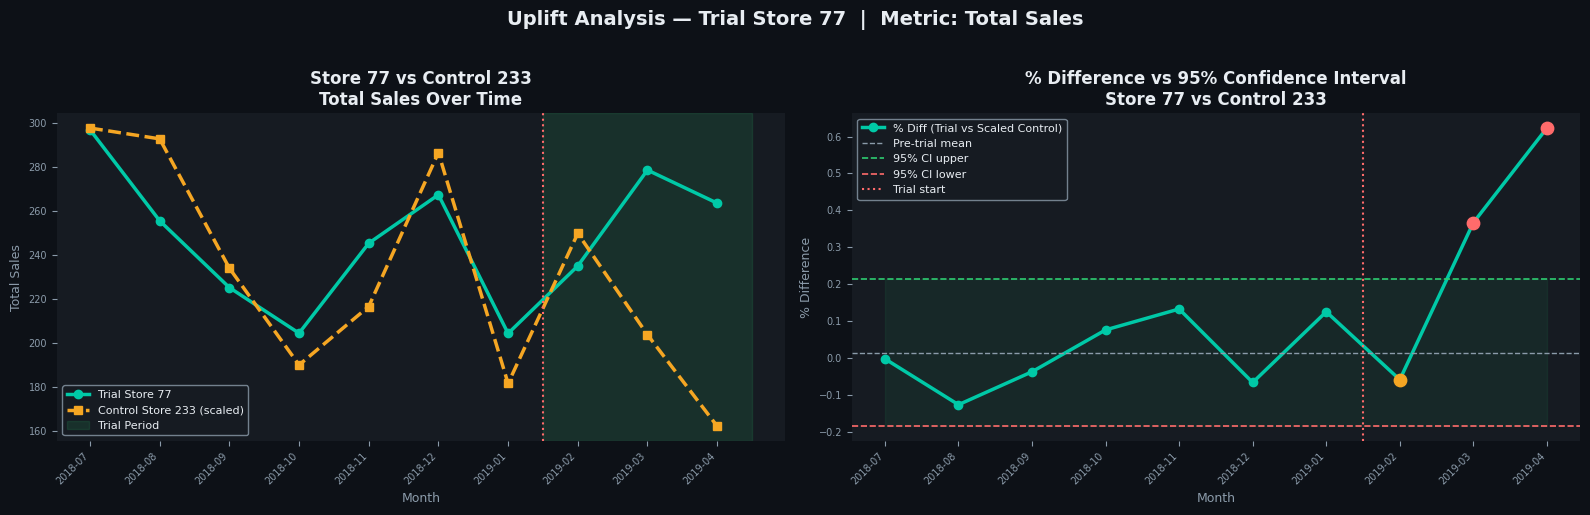


  Trial Store 77  vs  Control Store 233
  Metric: total_customers
  Scale factor          : 1.0034
  Pre-trial mean % diff : 0.24%
  95% CI                : [-5.25%, 5.72%]

  Trial period % diffs vs scaled control:
    2019-02  :  -0.33%  — within CI
    2019-03  :  24.58%  SIGNIFICANT
    2019-04  :  56.14%  SIGNIFICANT


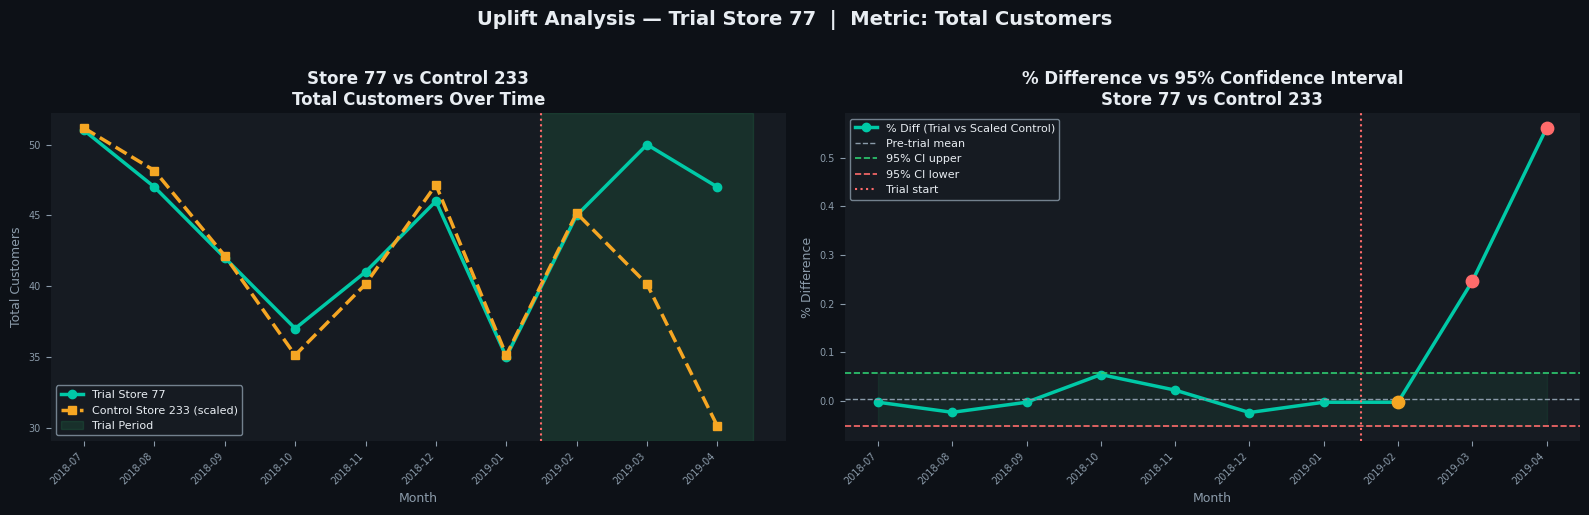


  Trial Store 77  vs  Control Store 233
  Metric: avg_txns_per_customer
  Scale factor          : 1.0189
  Pre-trial mean % diff : 0.08%
  95% CI                : [-9.33%, 9.49%]

  Trial period % diffs vs scaled control:
    2019-02  :  -6.03%  — within CI
    2019-03  :  5.33%  — within CI
    2019-04  :  -8.88%  — within CI


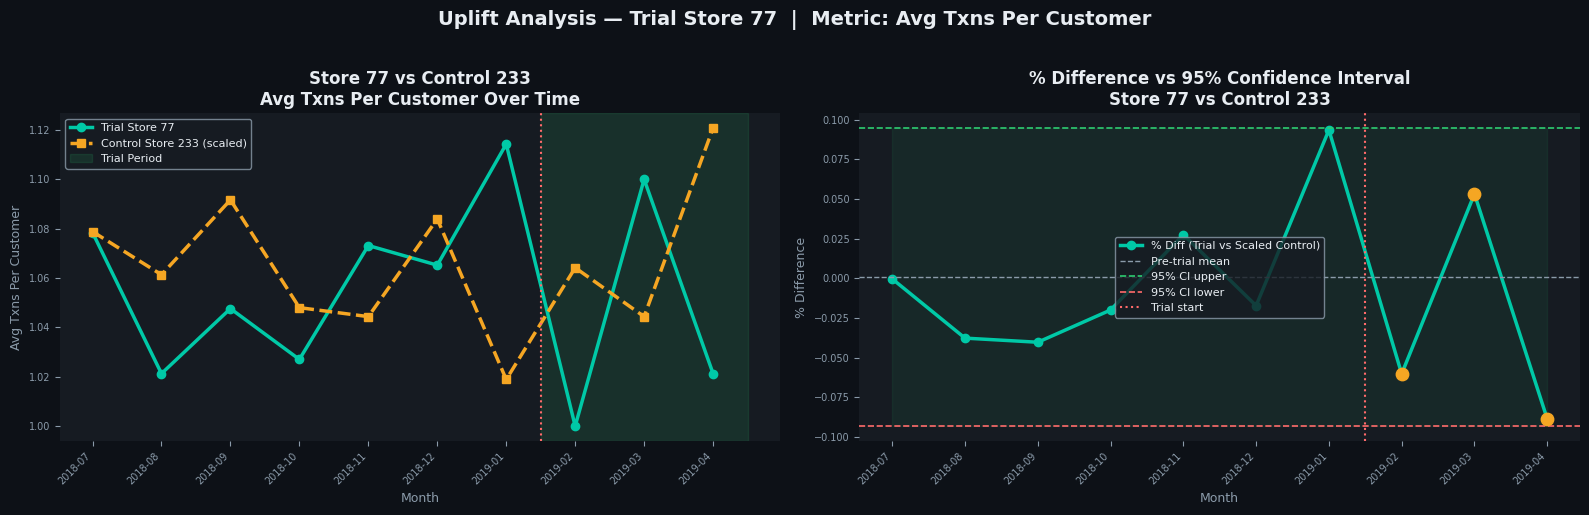


  Trial Store 86  vs  Control Store 155
  Metric: total_sales
  Scale factor          : 0.9701
  Pre-trial mean % diff : 0.14%
  95% CI                : [-7.40%, 7.68%]

  Trial period % diffs vs scaled control:
    2019-02  :  5.63%  — within CI
    2019-03  :  31.59%  SIGNIFICANT
    2019-04  :  3.53%  — within CI


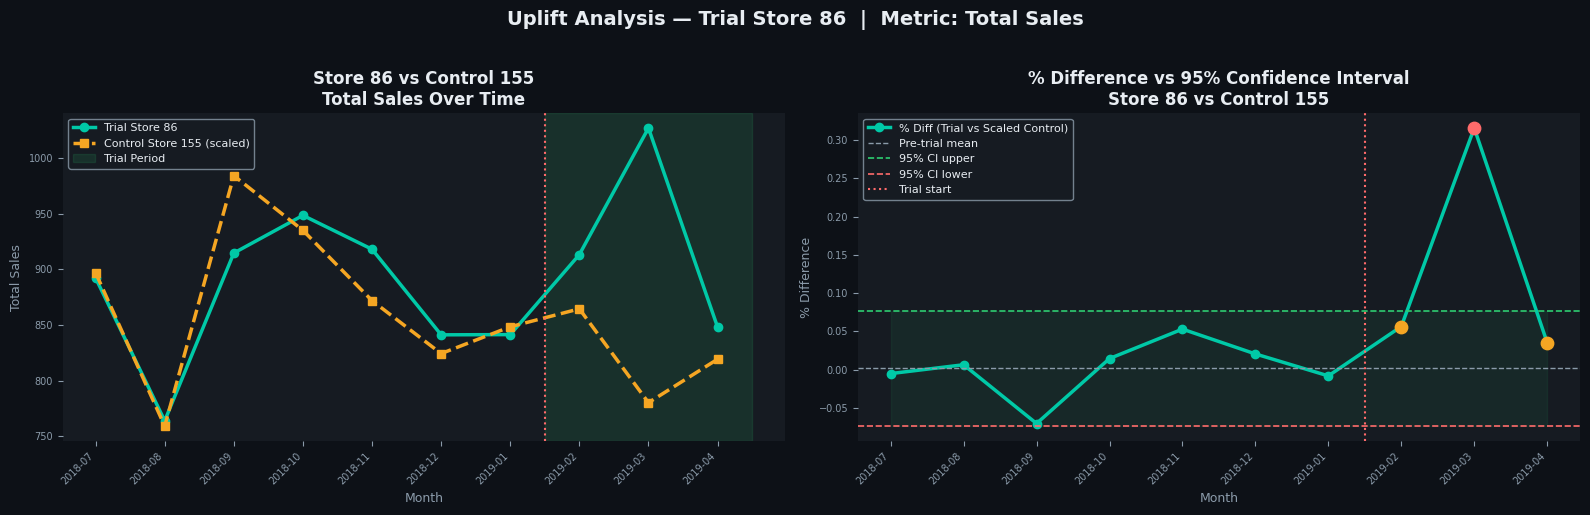


  Trial Store 86  vs  Control Store 155
  Metric: total_customers
  Scale factor          : 1.0000
  Pre-trial mean % diff : 0.03%
  95% CI                : [-3.80%, 3.86%]

  Trial period % diffs vs scaled control:
    2019-02  :  12.63%  SIGNIFICANT
    2019-03  :  22.34%  SIGNIFICANT
    2019-04  :  6.06%  SIGNIFICANT


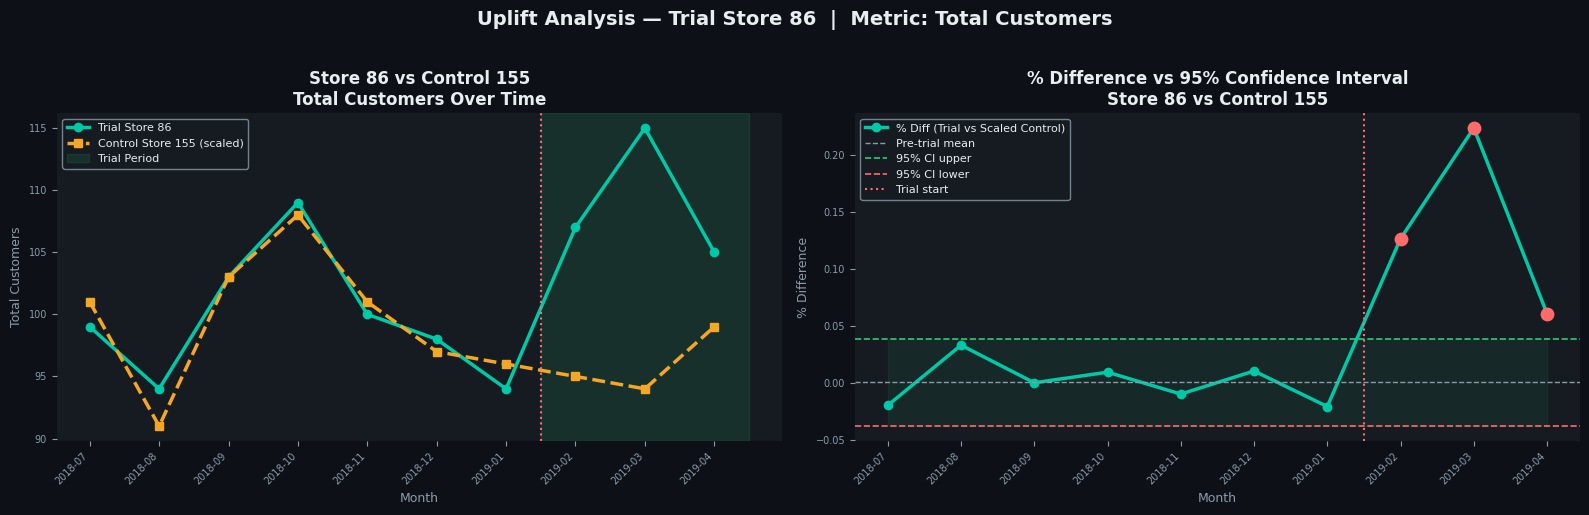


  Trial Store 86  vs  Control Store 155
  Metric: avg_txns_per_customer
  Scale factor          : 0.9715
  Pre-trial mean % diff : 0.17%
  95% CI                : [-12.57%, 12.92%]

  Trial period % diffs vs scaled control:
    2019-02  :  0.02%  — within CI
    2019-03  :  -0.44%  — within CI
    2019-04  :  1.86%  — within CI


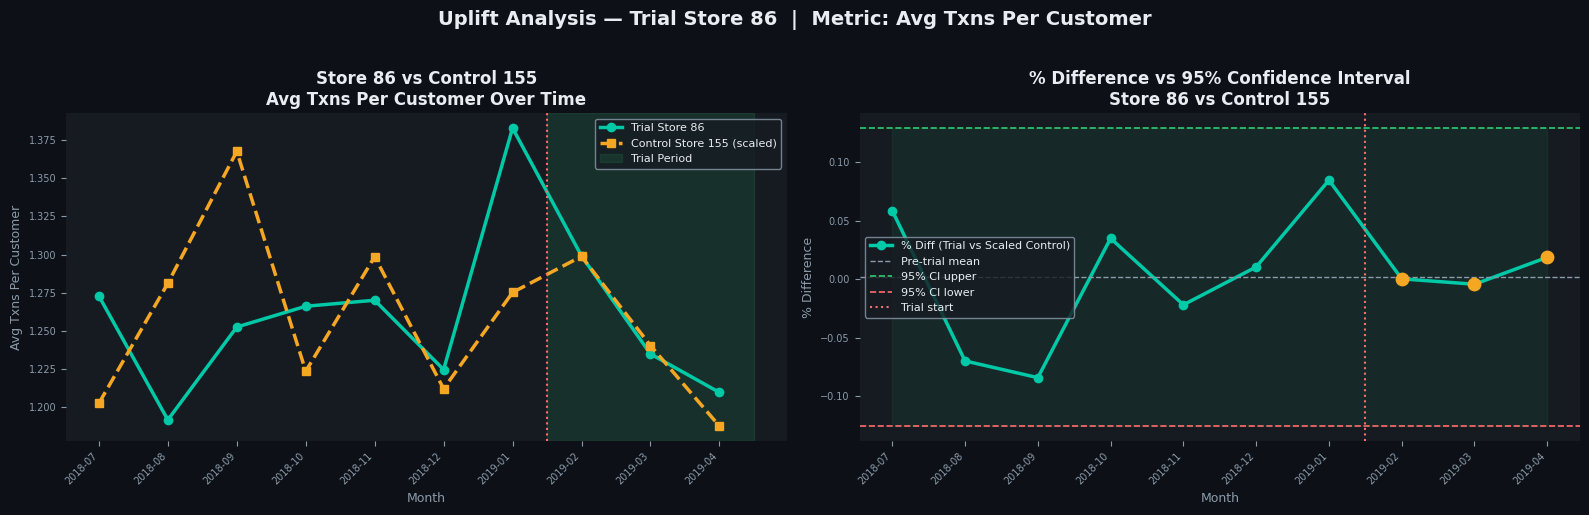


  Trial Store 88  vs  Control Store 125
  Metric: total_sales
  Scale factor          : 1.1718
  Pre-trial mean % diff : 0.17%
  95% CI                : [-8.99%, 9.34%]

  Trial period % diffs vs scaled control:
    2019-02  :  27.68%  SIGNIFICANT
    2019-03  :  2.04%  — within CI
    2019-04  :  10.84%  SIGNIFICANT


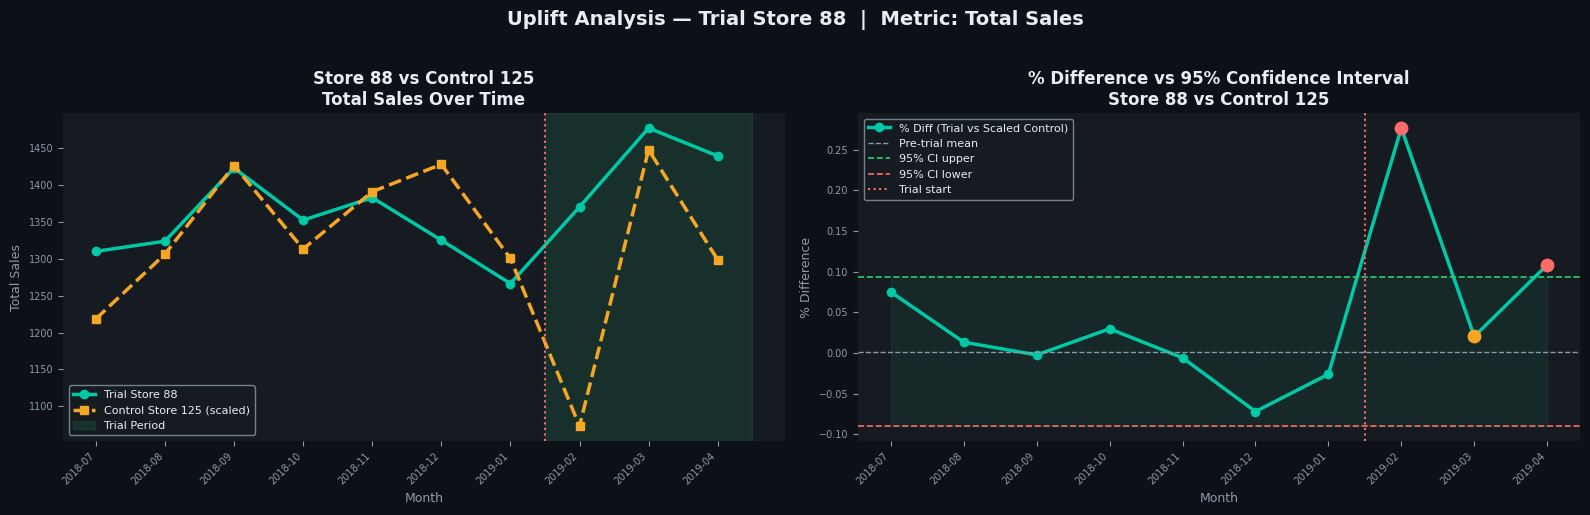


  Trial Store 88  vs  Control Store 125
  Metric: total_customers
  Scale factor          : 1.1097
  Pre-trial mean % diff : 0.56%
  95% CI                : [-18.02%, 19.15%]

  Trial period % diffs vs scaled control:
    2019-02  :  29.93%  SIGNIFICANT
    2019-03  :  -0.20%  — within CI
    2019-04  :  6.80%  — within CI


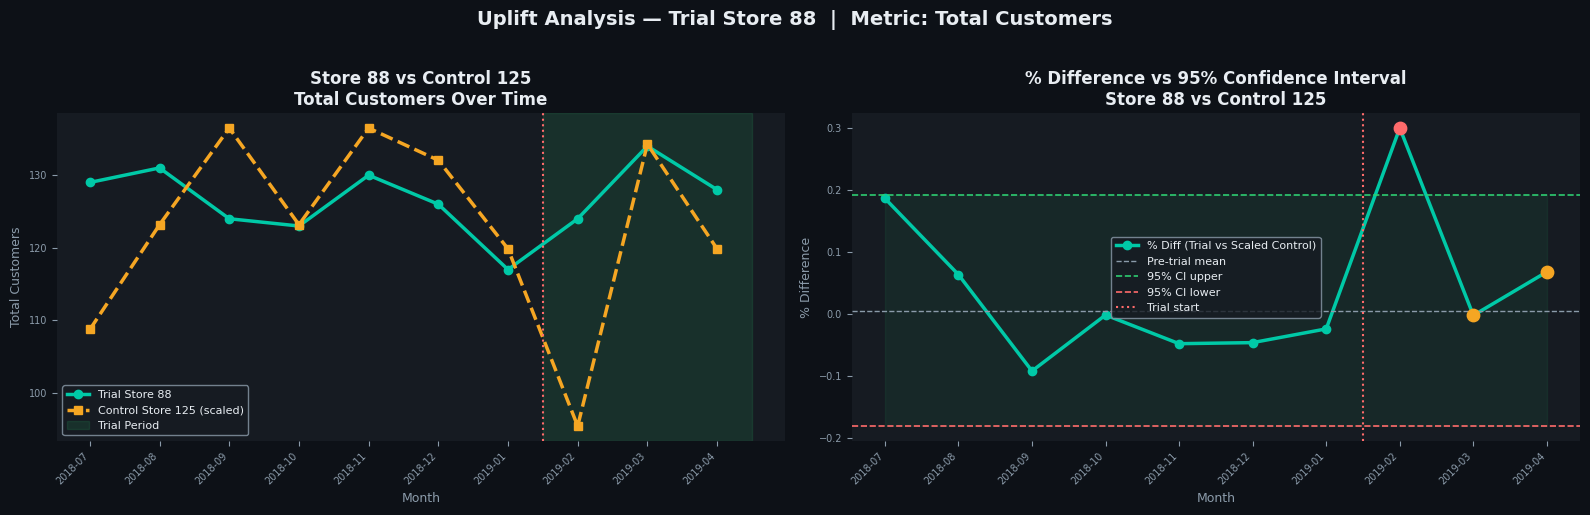


  Trial Store 88  vs  Control Store 125
  Metric: avg_txns_per_customer
  Scale factor          : 1.0472
  Pre-trial mean % diff : 0.16%
  95% CI                : [-12.11%, 12.43%]

  Trial period % diffs vs scaled control:
    2019-02  :  -1.93%  — within CI
    2019-03  :  3.97%  — within CI
    2019-04  :  5.27%  — within CI


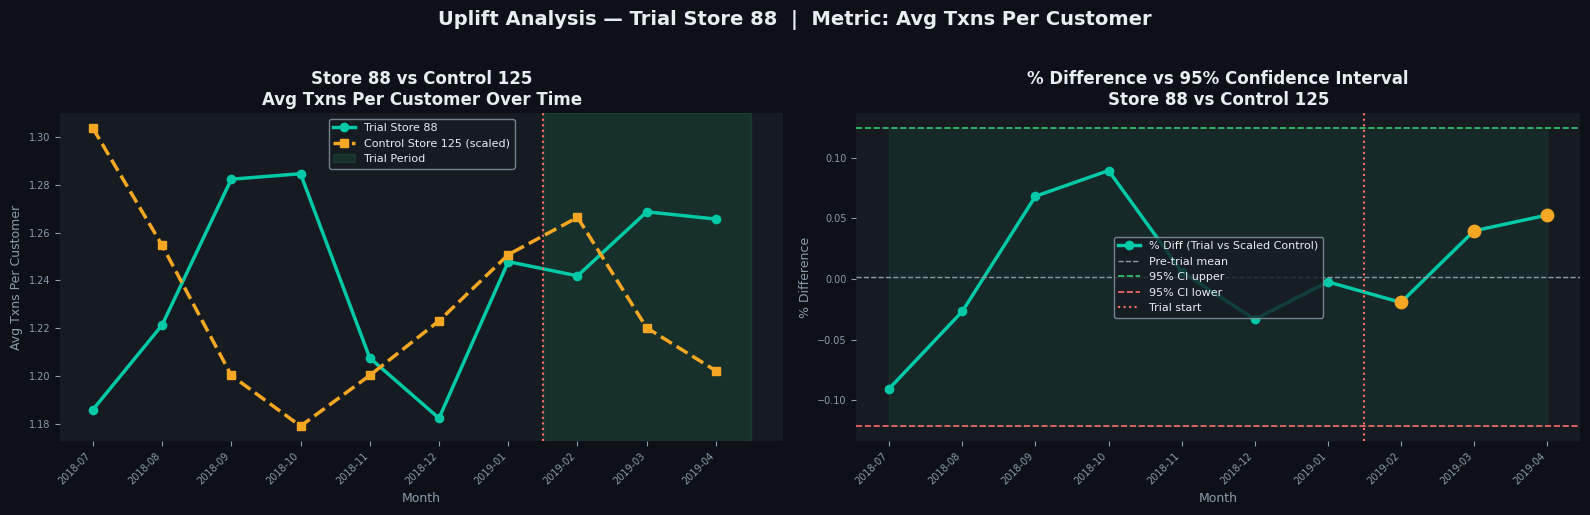

In [8]:
metrics = ['total_sales', 'total_customers', 'avg_txns_per_customer']
pairs   = [(77, ctrl_77), (86, ctrl_86), (88, ctrl_88)]

all_results = {}

for trial_store, control_store in pairs:
    all_results[trial_store] = {}
    for metric in metrics:
        result = uplift_test(trial_store, control_store, metric=metric)
        plot_uplift(result)
        all_results[trial_store][metric] = result

Block 8: Final Summary & Recommendation Table

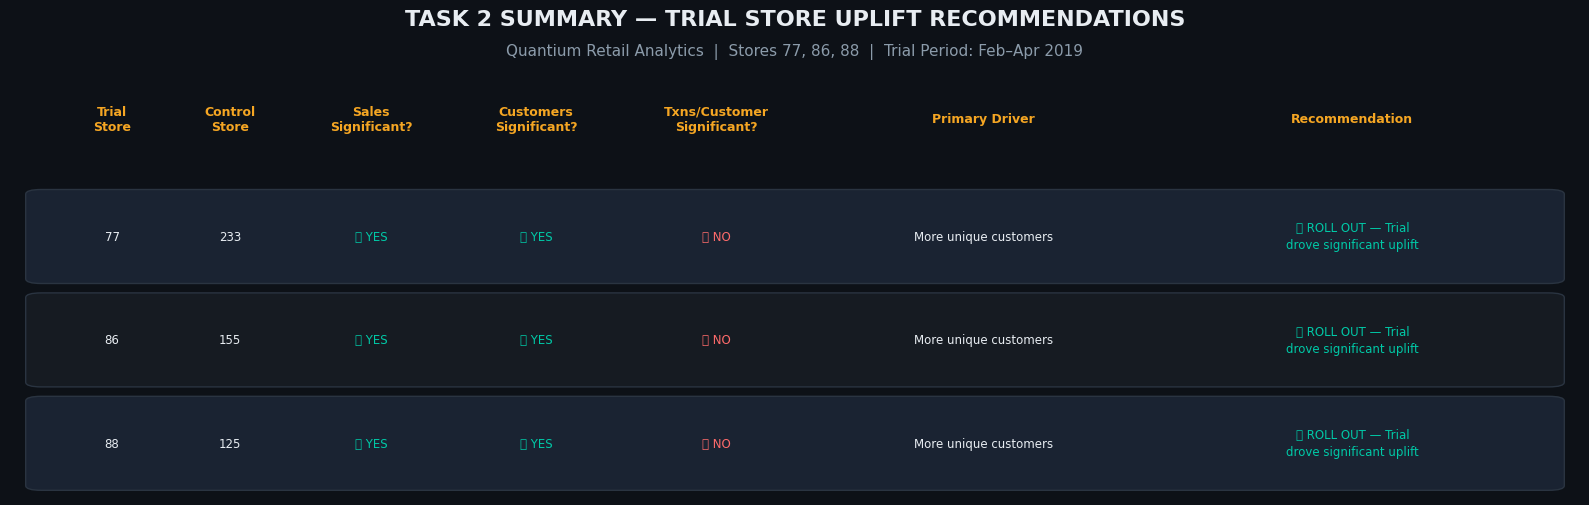


FINAL RECOMMENDATIONS FOR JULIA

Store 77 (Control: 233)
  Sales uplift significant : YES
  Avg trial uplift         : 31.02%
  Recommendation           : ROLL OUT ✅

Store 86 (Control: 155)
  Sales uplift significant : YES
  Avg trial uplift         : 13.58%
  Recommendation           : ROLL OUT ✅

Store 88 (Control: 125)
  Sales uplift significant : YES
  Avg trial uplift         : 13.52%
  Recommendation           : ROLL OUT ✅


In [9]:
BG      = '#0D1117'
CARD_BG = '#161B22'
TEAL    = '#00C9A7'
GOLD    = '#F5A623'
CORAL   = '#FF6B6B'
GREEN   = '#2ECC71'
DIM     = '#8B9BAA'
LIGHT   = '#E8EDF2'

def is_significant(result):
    ci_u = result['ci_upper']
    ci_l = result['ci_lower']
    return any(
        v > ci_u or v < ci_l
        for v in result['pct_diffs_trial'].values
    )

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.axis('off')

fig.text(0.5, 0.97,
         'TASK 2 SUMMARY — TRIAL STORE UPLIFT RECOMMENDATIONS',
         ha='center', fontsize=16, fontweight='bold', color=LIGHT)
fig.text(0.5, 0.91,
         'Quantium Retail Analytics  |  Stores 77, 86, 88  |  Trial Period: Feb–Apr 2019',
         ha='center', fontsize=11, color=DIM)

col_labels = ['Trial\nStore', 'Control\nStore',
              'Sales\nSignificant?', 'Customers\nSignificant?',
              'Txns/Customer\nSignificant?', 'Primary Driver', 'Recommendation']

rows = []
for ts, cs in pairs:
    r_sales = all_results[ts]['total_sales']
    r_cust  = all_results[ts]['total_customers']
    r_txns  = all_results[ts]['avg_txns_per_customer']

    sig_sales = is_significant(r_sales)
    sig_cust  = is_significant(r_cust)
    sig_txns  = is_significant(r_txns)

    if sig_cust and sig_txns:
        driver = 'Both: more customers\n& more txns/customer'
    elif sig_cust:
        driver = 'More unique customers'
    elif sig_txns:
        driver = 'More txns per customer'
    else:
        driver = 'No clear driver'

    if sig_sales:
        rec = '✅ ROLL OUT — Trial\ndrove significant uplift'
    else:
        rec = '⚠️ REVIEW — Uplift not\nstatistically significant'

    rows.append([
        str(ts), str(cs),
        '✅ YES' if sig_sales else '❌ NO',
        '✅ YES' if sig_cust  else '❌ NO',
        '✅ YES' if sig_txns  else '❌ NO',
        driver, rec
    ])

col_widths = [0.07, 0.08, 0.10, 0.11, 0.12, 0.22, 0.25]
x_positions = []
x = 0.03
for w in col_widths:
    x_positions.append(x + w / 2)
    x += w

y_header = 0.80
for i, (label, xp) in enumerate(zip(col_labels, x_positions)):
    ax.text(xp, y_header, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=9,
            fontweight='bold', color=GOLD)

for row_idx, row in enumerate(rows):
    y = 0.55 - row_idx * 0.22
    bg_color = '#1A2332' if row_idx % 2 == 0 else '#161B22'
    rect = mpatches.FancyBboxPatch(
        (0.02, y - 0.09), 0.96, 0.18,
        boxstyle="round,pad=0.01", linewidth=1,
        edgecolor='#2A3441', facecolor=bg_color,
        transform=ax.transAxes
    )
    ax.add_patch(rect)

    for col_idx, (val, xp) in enumerate(zip(row, x_positions)):
        color = TEAL  if '✅' in val else \
                CORAL if '❌' in val else \
                GREEN if 'ROLL' in val else LIGHT
        ax.text(xp, y, val, transform=ax.transAxes,
                ha='center', va='center', fontsize=8.5,
                color=color, linespacing=1.4)

plt.tight_layout()
plt.savefig('task2_final_recommendation.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── PRINT TEXT SUMMARY ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("FINAL RECOMMENDATIONS FOR JULIA")
print("="*60)
for ts, cs in pairs:
    r = all_results[ts]['total_sales']
    sig = is_significant(r)
    print(f"\nStore {ts} (Control: {cs})")
    print(f"  Sales uplift significant : {'YES' if sig else 'NO'}")
    avg_uplift = r['pct_diffs_trial'].mean()
    print(f"  Avg trial uplift         : {avg_uplift:.2%}")
    print(f"  Recommendation           : {'ROLL OUT ✅' if sig else 'REVIEW ⚠️'}")